# Segmentación de Clínicas

Las clínicas veterinarias dentro de la red Mexikans operan bajo el mismo marco organizativo, sin embargo, su desempeño operativo puede variar significativamente debido a factores como la ubicación, los patrones de demanda, el comportamiento de los clientes y la capacidad del personal.

Comprender estas diferencias operativas es importante para identificar oportunidades de mejorar la asignación de recursos, optimizar los niveles de personal y mejorar la prestación de servicios en toda la red.

En este notebook aplico **técnicas de aprendizaje no supervisado** para segmentar las clínicas según sus características operativas.

La segmentación de clínicas nos permite identificar patrones como:

- clínicas con alta demanda que operan cerca de su capacidad
- clínicas que generan mayores ingresos por visita
- clínicas subutilizadas con potencial de crecimiento
- clínicas con mayor intensidad de servicios de emergencia

El flujo de trabajo de segmentación sigue los siguientes pasos:

1. Cargar las características de desempeño de las clínicas  
2. Explorar métricas operativas  
3. Estandarizar las características  
4. Aplicar reducción de dimensionalidad utilizando PCA  
5. Determinar el número óptimo de clusters  
6. Realizar clustering utilizando K-Means  
7. Interpretar y perfilar los segmentos de clínicas resultantes  

Estos clusters proporcionan una visión basada en datos de la diversidad operativa dentro de la red de clínicas veterinarias Mexikans.

In [1]:
"""
Configuración del Entorno
"""

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Estilo visual consistente
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)

# Configuración de guardado de gráficos
NOTEBOOK_ID = "04_segmentation"

FIGURES_DIR = Path("../figures")

def save_plot(name):
    folder = FIGURES_DIR / NOTEBOOK_ID
    folder.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        folder / f"{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Entorno listo.")

Entorno listo.


## Cargar el Dataset de Desempeño de Clínicas

El análisis de segmentación de clínicas utiliza las características operativas creadas en el **notebook de Ingeniería de Características**.

Estas características resumen el desempeño operativo de cada clínica dentro de la red, incluyendo:

- intensidad de la demanda
- generación de ingresos
- productividad de los veterinarios
- utilización de la capacidad de la clínica
- proporción de visitas de emergencia

In [2]:
"""
Cargar Dataset
"""

DATA_PATH = "../data/"

clinic_df = pd.read_csv(
    DATA_PATH + "clinic_performance_features.csv"
)

clinic_df.head()

,clinic_id,city,number_of_veterinarians,clinic_capacity,clinic_popularity,opening_year,emergency_enabled,clinic_total_visits,clinic_total_revenue,clinic_avg_visit_revenue,clinic_unique_customers,clinic_unique_pets,emergency_visits,emergency_visit_ratio,clinic_revenue_per_visit,visits_per_veterinarian,revenue_per_veterinarian,capacity_utilization_ratio
0,C001,Chihuahua,4,36,0.822565,2017,False,11633,1628145.24,139.959189,2467,2654,0,0.000000,139.959189,2908.250000,407036.310000,323.138889
1,C002,San Luis Potosí,3,33,0.916858,2023,True,11712,1651985.20,141.050649,2471,2655,387,0.033043,141.050649,3904.000000,550661.733333,354.909091
2,C003,Chihuahua,5,40,1.186253,2011,False,18233,2549763.24,139.843319,3517,3893,0,0.000000,139.843319,3646.600000,509952.648000,455.825000
3,C004,San Luis Potosí,5,45,0.970062,2015,False,16921,2329779.13,137.685665,3273,3621,0,0.000000,137.685665,3384.200000,465955.826000,376.022222
4,C005,Tijuana,6,66,1.098928,2014,False,33497,5113080.30,152.642932,5198,6155,0,0.000000,152.642932,5582.833333,852180.050000,507.530303


## Visión General del Dataset

Antes de aplicar técnicas de clustering, es importante comprender la estructura del dataset y la distribución de las métricas operativas que se utilizarán para la segmentación.

Estas métricas representan indicadores clave del desempeño de las clínicas en toda la red Mexikans.

In [3]:
"""
Visión General del Dataset
"""

print("Tamaño del dataset:", clinic_df.shape)

clinic_df.describe()

Tamaño del dataset: (50, 18)


,number_of_veterinarians,clinic_capacity,clinic_popularity,opening_year,clinic_total_visits,clinic_total_revenue,clinic_avg_visit_revenue,clinic_unique_customers,clinic_unique_pets,emergency_visits,emergency_visit_ratio,clinic_revenue_per_visit,visits_per_veterinarian,revenue_per_veterinarian,capacity_utilization_ratio
count,50.000000,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,3.820000,36.280000,0.987211,2016.220000,15068.820000,2.237565e+06,148.882826,2941.780000,3241.860000,122.400000,0.010775,148.882826,3950.414000,590421.994670,411.838899
std,1.466497,14.557472,0.111077,3.850735,6902.487471,1.010190e+06,11.413995,942.810351,1154.685044,194.082772,0.015902,11.413995,787.979869,139138.759253,56.558950
min,2.000000,16.000000,0.815534,2010.000000,6630.000000,9.368644e+05,134.330257,1703.000000,1771.000000,0.000000,0.000000,134.330257,2701.000000,393450.480000,317.133333
25%,3.000000,24.000000,0.911400,2013.000000,10021.750000,1.445636e+06,139.839415,2244.500000,2405.500000,0.000000,0.000000,139.839415,3380.300000,471983.284375,366.884028
50%,4.000000,32.500000,0.966822,2015.500000,12628.500000,1.874803e+06,145.503121,2653.000000,2877.000000,0.000000,0.000000,145.503121,3721.300000,561459.360000,408.717045
75%,5.000000,44.750000,1.080942,2019.000000,17905.000000,2.822531e+06,154.058124,3466.250000,3833.000000,254.750000,0.032113,154.058124,4438.750000,667809.972083,454.255114
max,6.000000,66.000000,1.193369,2023.000000,33497.000000,5.113080e+06,176.851599,5198.000000,6155.000000,672.000000,0.037870,176.851599,5582.833333,943638.130000,540.900000


## Distribución de Métricas Operativas

Las siguientes visualizaciones muestran cómo varían los indicadores operativos entre las clínicas de la red.

Comprender la distribución de estas métricas ayuda a identificar la variabilidad en el desempeño de las clínicas y proporciona una intuición inicial sobre posibles patrones de segmentación.

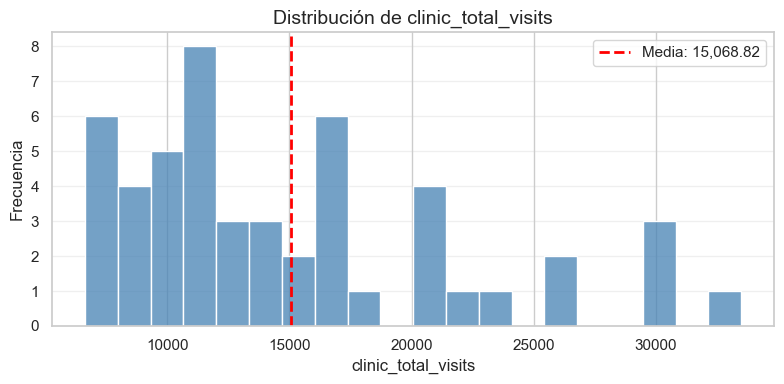

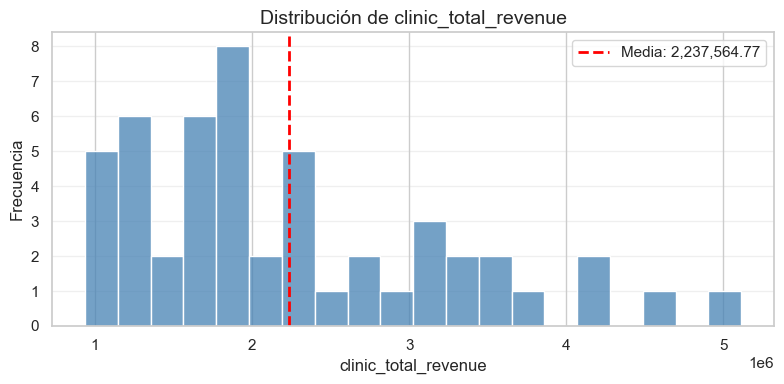

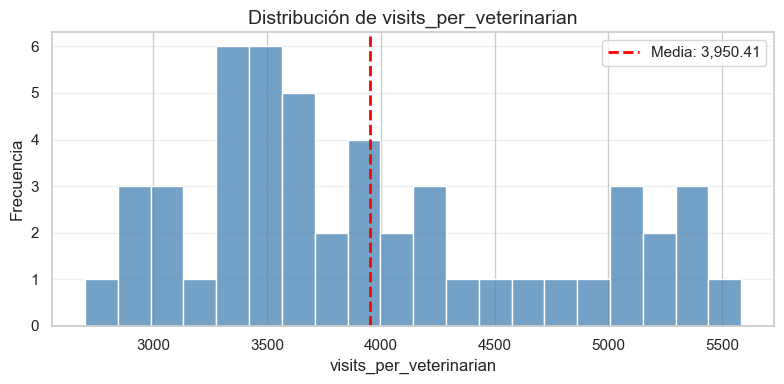

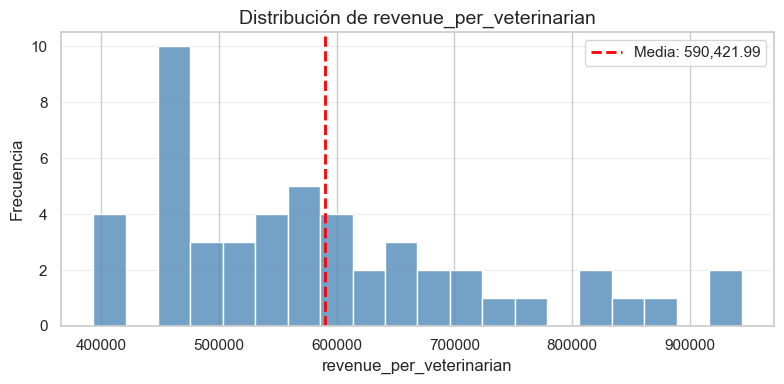

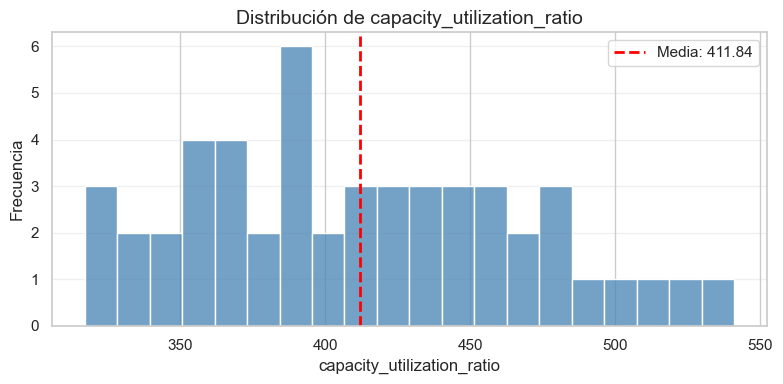

In [4]:
metrics = [
    "clinic_total_visits",
    "clinic_total_revenue",
    "visits_per_veterinarian",
    "revenue_per_veterinarian",
    "capacity_utilization_ratio"
]

for m in metrics:

    plt.figure(figsize=(8,4))

    sns.histplot(
        clinic_df[m],
        bins=20,
        color="steelblue"
    )

    mean_val = clinic_df[m].mean()

    plt.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Media: {mean_val:,.2f}"
    )

    plt.title(f"Distribución de {m}")
    plt.xlabel(m)
    plt.ylabel("Frecuencia")

    plt.legend()

    plt.grid(axis="y", alpha=0.3)

    save_plot(f"{m}_distribution")

    plt.tight_layout()

    plt.show()

## Selección de Características para Segmentación

No todas las variables del dataset de clínicas son adecuadas para clustering.

Para fines de segmentación, selecciono métricas operativas que describen dimensiones clave del desempeño de las clínicas:

- intensidad de la demanda
- generación de ingresos
- estructura de precios de los servicios
- productividad de los veterinarios
- utilización de la capacidad
- intensidad de servicios de emergencia

En conjunto, estos indicadores proporcionan una visión integral de las operaciones de las clínicas.

In [5]:
"""
Selección de Características
"""

segmentation_features = clinic_df[
    [
        "clinic_total_visits",
        "clinic_total_revenue",
        "clinic_revenue_per_visit",
        "visits_per_veterinarian",
        "revenue_per_veterinarian",
        "capacity_utilization_ratio",
        "emergency_visit_ratio"
    ]
]

segmentation_features.head()

,clinic_total_visits,clinic_total_revenue,clinic_revenue_per_visit,visits_per_veterinarian,revenue_per_veterinarian,capacity_utilization_ratio,emergency_visit_ratio
0,11633,1628145.24,139.959189,2908.250000,407036.310000,323.138889,0.000000
1,11712,1651985.20,141.050649,3904.000000,550661.733333,354.909091,0.033043
2,18233,2549763.24,139.843319,3646.600000,509952.648000,455.825000,0.000000
3,16921,2329779.13,137.685665,3384.200000,465955.826000,376.022222,0.000000
4,33497,5113080.30,152.642932,5582.833333,852180.050000,507.530303,0.000000


## Escalado de Características

Los algoritmos de clustering como K-Means son sensibles a la escala de las variables de entrada.

Las métricas operativas en el dataset de clínicas tienen magnitudes muy diferentes. Por ejemplo, los ingresos totales de una clínica pueden ser varios órdenes de magnitud mayores que ratios como la utilización de capacidad.

Para asegurar que todas las características contribuyan de manera equilibrada al proceso de clustering, estandarizo las variables utilizando **StandardScaler**, que transforma cada característica para que tenga:

- media igual a 0
- desviación estándar igual a 1

Este paso evita que las variables con rangos numéricos más grandes dominen el proceso de clustering.

In [6]:
"""
Escalado de Características
"""

scaler = StandardScaler()

scaled_features = scaler.fit_transform(segmentation_features)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=segmentation_features.columns
)

scaled_df.head()

,clinic_total_visits,clinic_total_revenue,clinic_revenue_per_visit,visits_per_veterinarian,revenue_per_veterinarian,capacity_utilization_ratio,emergency_visit_ratio
0,-0.502819,-0.609397,-0.789753,-1.336004,-1.331387,-1.584197,-0.684465
1,-0.491258,-0.585558,-0.693157,-0.059501,-0.288661,-1.016776,1.414495
2,0.463066,0.312187,-0.800007,-0.389475,-0.584210,0.785599,-0.684465
3,0.271059,0.092211,-0.990962,-0.725859,-0.903629,-0.639692,-0.684465
4,2.696893,2.875410,0.332774,2.092684,1.900373,1.709065,-0.684465


## Análisis de Componentes Principales (PCA)

Antes de aplicar clustering, realizo un **Análisis de Componentes Principales (PCA)** para explorar la estructura subyacente de los datos de desempeño de las clínicas.

PCA reduce la dimensionalidad del dataset transformando variables correlacionadas en un conjunto más pequeño de componentes ortogonales que capturan la mayor parte de la varianza en los datos.

Este análisis ayuda a responder dos preguntas clave:

- ¿Cuántas dimensiones explican la mayor parte de la variabilidad entre las clínicas?
- ¿Las clínicas muestran una estructura natural en el espacio de características?

Comprender estos patrones puede proporcionar intuición sobre la posible formación de clusters.

In [7]:
"""
Análisis de PCA
"""

pca = PCA()

pca_features = pca.fit_transform(scaled_df)

explained_variance = pca.explained_variance_ratio_

## Varianza Explicada

La siguiente visualización muestra la proporción acumulada de varianza explicada por los componentes principales.

Esto ayuda a determinar cuántos componentes son necesarios para capturar la mayor parte de la variabilidad en el desempeño de las clínicas.

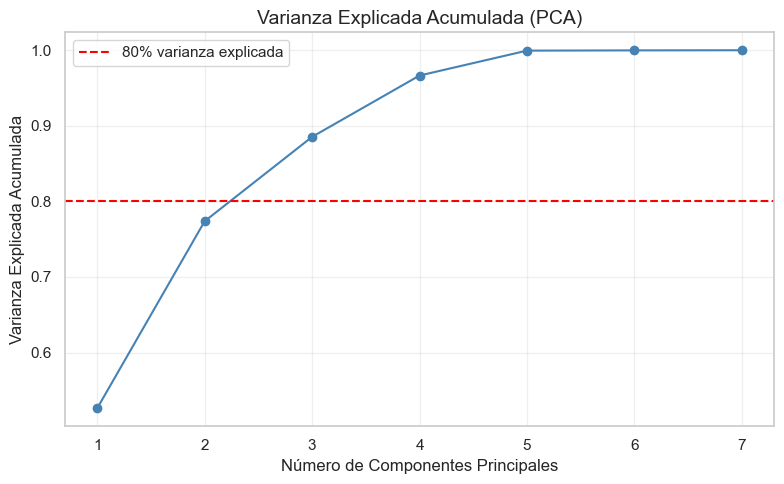

In [8]:
plt.figure(figsize=(8,5))

cum_var = np.cumsum(explained_variance)

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker="o",
    color="steelblue"
)

plt.axhline(
    0.8,
    color="red",
    linestyle="--",
    label="80% varianza explicada"
)

plt.title("Varianza Explicada Acumulada (PCA)")
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Varianza Explicada Acumulada")

plt.legend()

plt.grid(alpha=0.3)

save_plot("pca_cumulative_variance")

plt.tight_layout()

plt.show()

## Proyección PCA

Para visualizar la estructura del dataset de clínicas, proyecto el espacio de características estandarizadas sobre los dos primeros componentes principales.

Esta proyección permite observar si las clínicas forman grupos de manera natural en el espacio reducido de características antes de aplicar algoritmos de clustering.

In [9]:
"""
Proyección PCA
"""

pca = PCA(n_components=2)

pca_projection = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_projection,
    columns=["PC1","PC2"]
)

pca_df.head()

,PC1,PC2
0,-2.419520,-1.173084
1,-1.422909,0.441505
2,0.164581,-1.195862
3,-0.981261,-1.512541
4,4.970632,-1.209198


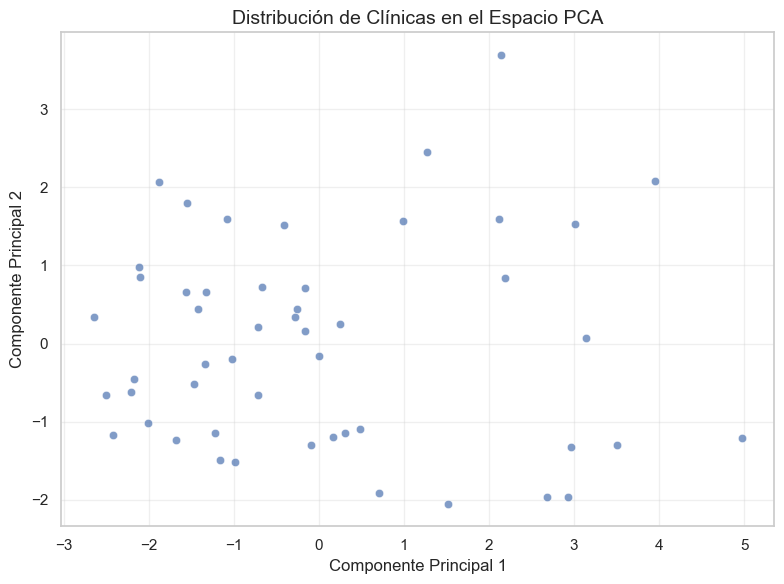

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    alpha=0.7
)

plt.title("Distribución de Clínicas en el Espacio PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.grid(alpha=0.3)

save_plot("pca_clinic_distribution")

plt.tight_layout()

plt.show()

## Determinación del Número Óptimo de Clusters

Elegir el número correcto de clusters es una de las decisiones más importantes en el análisis de clustering.

Si el número de clusters es demasiado pequeño, pueden ocultarse diferencias operativas importantes entre las clínicas. Si el número de clusters es demasiado grande, la segmentación puede volverse inestable y difícil de interpretar.

Para determinar un número adecuado de clusters, evalúo dos métodos de diagnóstico:

**Método del Codo (Elbow Method)**

Este método analiza cómo la inercia del clustering (varianza dentro de los clusters) disminuye a medida que aumenta el número de clusters.

**Coeficiente de Silueta (Silhouette Score)**

Esta métrica evalúa qué tan bien se ajusta cada observación a su cluster asignado en comparación con otros clusters. Valores más altos del coeficiente de silueta indican una mejor separación entre clusters.

Utilizar ambos enfoques proporciona una base más confiable para seleccionar el número de clusters.

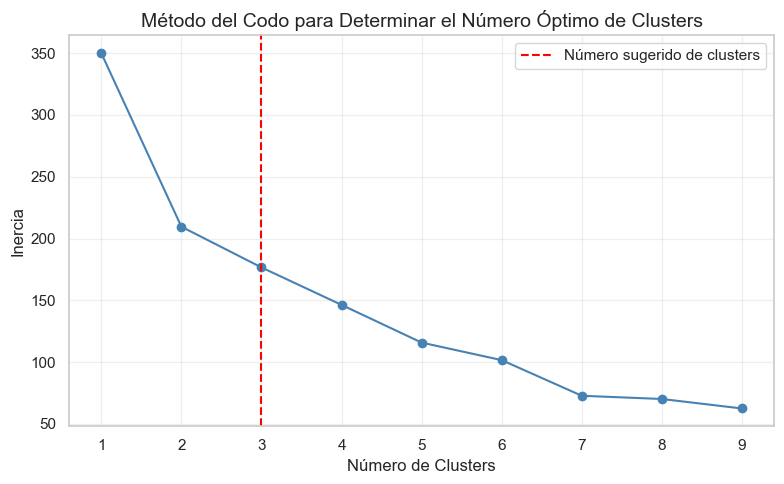

In [11]:
"""
Método del Codo
"""

inertia = []

k_range = range(1,10)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_df)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    inertia,
    marker="o",
    color="steelblue"
)

# linha sugerindo número ideal de clusters (exemplo: 3)
plt.axvline(
    3,
    linestyle="--",
    color="red",
    label="Número sugerido de clusters"
)

plt.title("Método del Codo para Determinar el Número Óptimo de Clusters")

plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")

plt.legend()

plt.grid(alpha=0.3)

save_plot("kmeans_elbow_method")

plt.tight_layout()

plt.show()

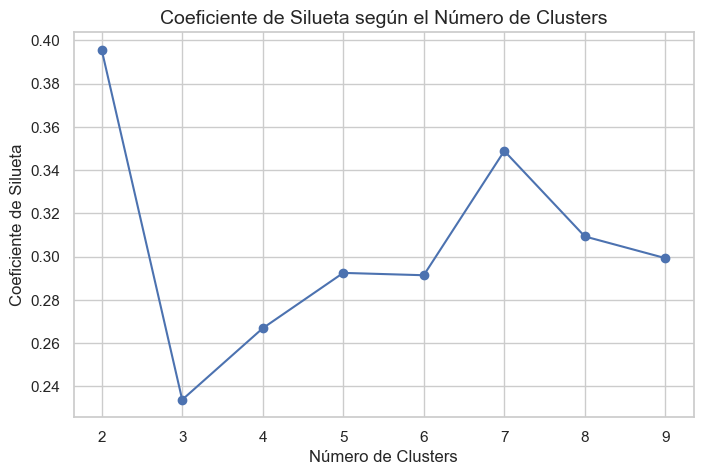

In [12]:
"""
Coeficiente de Silueta
"""

silhouette_scores = []

k_range = range(2,10)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(scaled_df)

    score = silhouette_score(
        scaled_df,
        labels
    )

    silhouette_scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o"
)

plt.title("Coeficiente de Silueta según el Número de Clusters")

plt.xlabel("Número de Clusters")

plt.ylabel("Coeficiente de Silueta")

plt.show()

## Selección de la Configuración Final de Clusters

Con base en el análisis del Método del Codo y del Coeficiente de Silueta, una configuración de **cuatro clusters** proporciona un equilibrio razonable entre la simplicidad del modelo y la separación entre clusters.

El uso de cuatro clusters permite capturar diferencias operativas significativas entre las clínicas mientras se mantiene la interpretabilidad para el análisis de negocio.

En el siguiente paso entreno el modelo final de K-Means utilizando esta configuración y analizo los segmentos de clínicas resultantes.

## Clustering Final con K-Means

Después de evaluar diferentes configuraciones de clustering, entreno el modelo final de K-Means utilizando cuatro clusters.

Este modelo agrupa las clínicas según las similitudes en sus indicadores de desempeño operativo.

Los clusters resultantes representan diferentes tipos de clínicas dentro de la red Mexikans, lo que puede revelar patrones relacionados con la intensidad de la demanda, la eficiencia operativa y la estructura de los servicios.

In [13]:
"""
Modelo Final de K-Means
"""

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_df)

clinic_df["cluster"] = clusters

clinic_df.head()

,clinic_id,city,number_of_veterinarians,clinic_capacity,clinic_popularity,opening_year,emergency_enabled,clinic_total_visits,clinic_total_revenue,clinic_avg_visit_revenue,clinic_unique_customers,clinic_unique_pets,emergency_visits,emergency_visit_ratio,clinic_revenue_per_visit,visits_per_veterinarian,revenue_per_veterinarian,capacity_utilization_ratio,cluster
0,C001,Chihuahua,4,36,0.822565,2017,False,11633,1628145.24,139.959189,2467,2654,0,0.000000,139.959189,2908.250000,407036.310000,323.138889,0
1,C002,San Luis Potosí,3,33,0.916858,2023,True,11712,1651985.20,141.050649,2471,2655,387,0.033043,141.050649,3904.000000,550661.733333,354.909091,3
2,C003,Chihuahua,5,40,1.186253,2011,False,18233,2549763.24,139.843319,3517,3893,0,0.000000,139.843319,3646.600000,509952.648000,455.825000,0
3,C004,San Luis Potosí,5,45,0.970062,2015,False,16921,2329779.13,137.685665,3273,3621,0,0.000000,137.685665,3384.200000,465955.826000,376.022222,0
4,C005,Tijuana,6,66,1.098928,2014,False,33497,5113080.30,152.642932,5198,6155,0,0.000000,152.642932,5582.833333,852180.050000,507.530303,2


## Visualización de Clusters

Para comprender mejor la estructura de los clusters, visualizo las clínicas en el espacio bidimensional de PCA creado anteriormente.

Esta proyección permite observar cómo las clínicas se agrupan según sus características operativas.

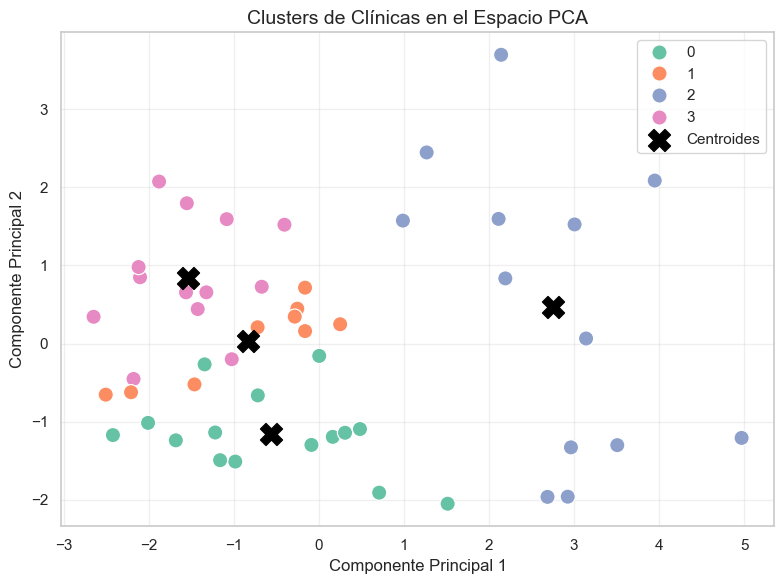

In [14]:
pca_df["cluster"] = clusters

plt.figure(figsize=(8,6))

ax = sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=120
)

# calcular centroides dos clusters
centroids = pca_df.groupby("cluster")[["PC1","PC2"]].mean()

plt.scatter(
    centroids["PC1"],
    centroids["PC2"],
    c="black",
    s=250,
    marker="X",
    label="Centroides"
)

plt.title("Clusters de Clínicas en el Espacio PCA")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.legend()

plt.grid(alpha=0.3)

save_plot("clinic_clusters_pca")

plt.tight_layout()

plt.show()

## Distribución del Tamaño de los Clusters

Comprender cómo se distribuyen las clínicas entre los distintos clusters ayuda a evaluar el equilibrio de la segmentación.

Un cluster muy pequeño puede indicar un patrón operativo específico o poco común, mientras que clusters más grandes pueden representar tipos de clínicas más comunes dentro de la red.

/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_2781/741489366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


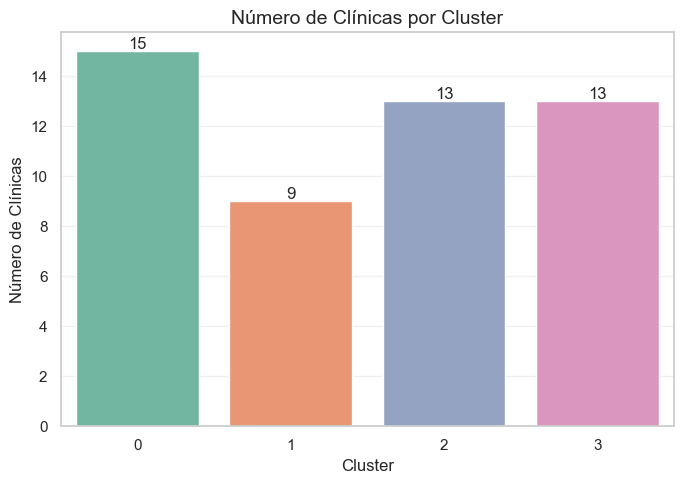

In [15]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x="cluster",
    data=clinic_df,
    palette="Set2"
)

plt.title("Número de Clínicas por Cluster")

plt.xlabel("Cluster")
plt.ylabel("Número de Clínicas")

# adicionar valores nas barras
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,
        p.get_height() + 0.1,
        int(p.get_height()),
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

save_plot("clinics_per_cluster")

plt.tight_layout()

plt.show()

## Perfilado de Clusters

Para interpretar el significado de cada cluster, calculo el valor promedio de las métricas operativas para las clínicas que pertenecen a cada segmento.

Este análisis ayuda a identificar las características que diferencian a cada cluster, como la intensidad de la demanda, la generación de ingresos, la productividad de los veterinarios y los patrones de servicio.

In [16]:
cluster_profile = (
    clinic_df
    .groupby("cluster")
    [
        [
            "clinic_total_visits",
            "clinic_total_revenue",
            "clinic_revenue_per_visit",
            "visits_per_veterinarian",
            "revenue_per_veterinarian",
            "capacity_utilization_ratio",
            "emergency_visit_ratio"
        ]
    ]
    .mean()
)

cluster_profile

,clinic_total_visits,clinic_total_revenue,clinic_revenue_per_visit,visits_per_veterinarian,revenue_per_veterinarian,capacity_utilization_ratio,emergency_visit_ratio
cluster,,,,,,,
0,17205.933333,2.475813e+06,144.051131,3447.907778,495820.527211,387.434738,0.000000
1,9099.333333,1.303523e+06,142.743847,3983.592593,568989.840926,403.130415,0.000000
2,20981.461538,3.241252e+06,158.535213,4951.266667,782112.725372,485.526209,0.007773
3,10823.000000,1.605620e+06,149.055534,3506.406410,522724.448244,372.339185,0.033671


## Comparación de Características entre Clusters

Para visualizar mejor las diferencias entre los clusters, creo un mapa de calor que muestra la intensidad relativa de cada métrica operativa en los distintos segmentos.

Esta visualización facilita identificar el perfil operativo de cada segmento de clínicas.

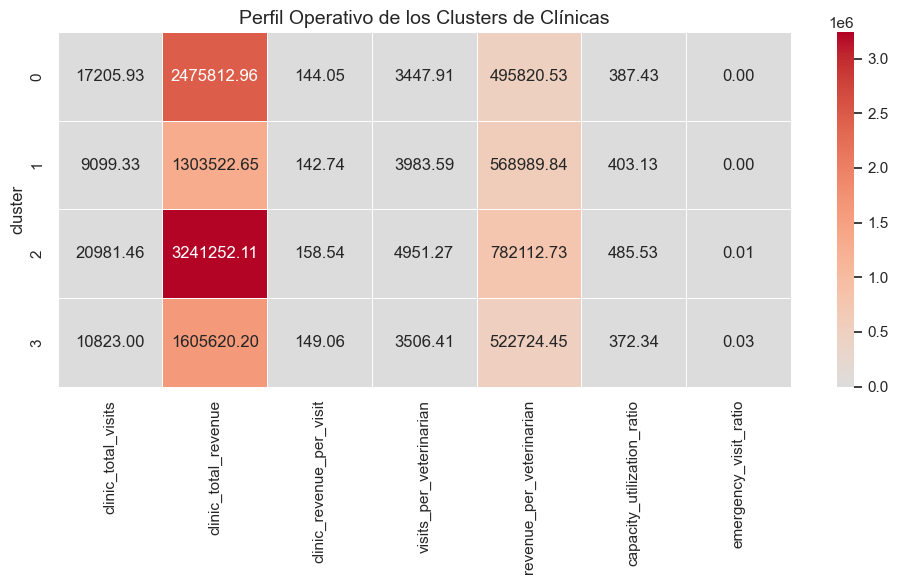

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Perfil Operativo de los Clusters de Clínicas")

save_plot("cluster_operational_profile")

plt.tight_layout()

plt.show()

## Interpretación de Clusters

El análisis de clustering revela la existencia de distintos perfiles operativos entre las clínicas veterinarias de la red Mexikans.

Aunque todas las clínicas ofrecen servicios similares, las diferencias en volumen de pacientes, generación de ingresos, productividad del personal veterinario y niveles de utilización de capacidad permiten identificar segmentos operativos claramente diferenciados.

A partir del perfil promedio de cada cluster, se pueden interpretar los segmentos de la siguiente manera:

### Cluster 2 — Clínicas de Alto Rendimiento

Este segmento presenta los niveles más altos de actividad en la red.

Las clínicas del Cluster 2 registran:

- el mayor número de visitas totales
- los ingresos totales más elevados
- el mayor ingreso promedio por visita
- la mayor productividad por veterinario
- los niveles más altos de utilización de capacidad

Esto sugiere que estas clínicas operan como **centros de alta actividad dentro de la red**, con una fuerte demanda de pacientes y una utilización intensiva de recursos.

Implicaciones operativas:

- posible presión sobre la capacidad operativa
- necesidad de planificación cuidadosa de personal
- oportunidad para expansión de infraestructura o personal veterinario

---

### Cluster 0 — Clínicas de Alta Demanda Estable

Las clínicas en este segmento también presentan un volumen elevado de visitas y altos niveles de ingresos, aunque ligeramente inferiores al cluster de mayor rendimiento.

En comparación con el Cluster 2, estas clínicas muestran:

- altos niveles de actividad
- ingresos significativos
- productividad moderada por veterinario

Estas clínicas parecen operar como **centros importantes dentro de la red**, pero con una carga operativa ligeramente menor que las clínicas del cluster de mayor rendimiento.

Implicaciones operativas:

- operación relativamente estable
- posibilidad de optimizar la productividad del personal
- potencial de crecimiento moderado

---

### Cluster 1 — Clínicas de Menor Volumen con Buena Productividad

Las clínicas del Cluster 1 presentan el menor número de visitas totales dentro de la red, así como menores ingresos agregados.

Sin embargo, estas clínicas muestran **niveles relativamente altos de visitas por veterinario**, lo que sugiere una buena eficiencia operativa a pesar del menor volumen de pacientes.

Este perfil puede reflejar clínicas:

- ubicadas en mercados más pequeños
- con estructuras operativas más compactas
- con una utilización eficiente del personal disponible

Implicaciones operativas:

- modelos de operación más eficientes
- menor presión sobre la infraestructura
- posibilidad de crecimiento mediante expansión de la base de pacientes

---

### Cluster 3 — Clínicas de Rendimiento Intermedio

Las clínicas agrupadas en el Cluster 3 presentan valores intermedios en la mayoría de las métricas analizadas.

En términos generales, este segmento muestra:

- niveles moderados de visitas
- ingresos intermedios dentro de la red
- productividad relativamente equilibrada por veterinario
- niveles de utilización de capacidad estables

Estas clínicas pueden considerarse como **operaciones equilibradas**, sin niveles extremos de demanda ni de presión operativa.

Implicaciones operativas:

- operación estable
- menor riesgo de saturación operativa
- oportunidades graduales de optimización o crecimiento

---

En conjunto, esta segmentación proporciona una visión basada en datos de la diversidad operativa dentro de la red de clínicas veterinarias Mexikans.

Comprender estos perfiles permite apoyar estrategias de gestión diferenciadas para cada tipo de clínica, optimizando la asignación de recursos y la planificación operativa en toda la red.